IMport LIbraries

In [2]:
import os
import random
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Dataset Paths

In [3]:
TRAIN_PATH = "../dataset/PlantVillage/train"
VAL_PATH = "../dataset/PlantVillage/val"

Verify Dataset

In [4]:
classes = os.listdir(TRAIN_PATH)

print("Number of Classes:", len(classes))
print("\nClasses:\n")
print(classes)

Number of Classes: 38

Classes:

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___healthy', 'Corn_(maize)___Northern_Leaf_Blight', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___healthy', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___healthy', 'Potato___Late_blight', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___healthy', 'Strawberry___Leaf_scorch', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___healthy', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spide

Dataset Statistics

In [5]:
data = []

for cls in classes:
    count = len(os.listdir(os.path.join(TRAIN_PATH, cls)))
    data.append([cls, count])

df = pd.DataFrame(data, columns=["Class", "Training Images"])

df

,Class,Training Images
0,Apple___Apple_scab,504
1,Apple___Black_rot,496
2,Apple___Cedar_apple_rust,220
3,Apple___healthy,1316
4,Blueberry___healthy,1202
5,Cherry_(including_sour)___healthy,684
6,Cherry_(including_sour)___Powdery_mildew,842
7,Corn_(maize)___Cercospora_leaf_spot Gray_leaf_...,410
8,Corn_(maize)___Common_rust_,953
9,Corn_(maize)___healthy,929


Total Images

In [6]:
total_images = 0

for cls in classes:
    total_images += len(
        os.listdir(os.path.join(TRAIN_PATH, cls))
    )

print("Total Classes:", len(classes))
print("Total Training Images:", total_images)

Total Classes: 38
Total Training Images: 43444


Class Distribution

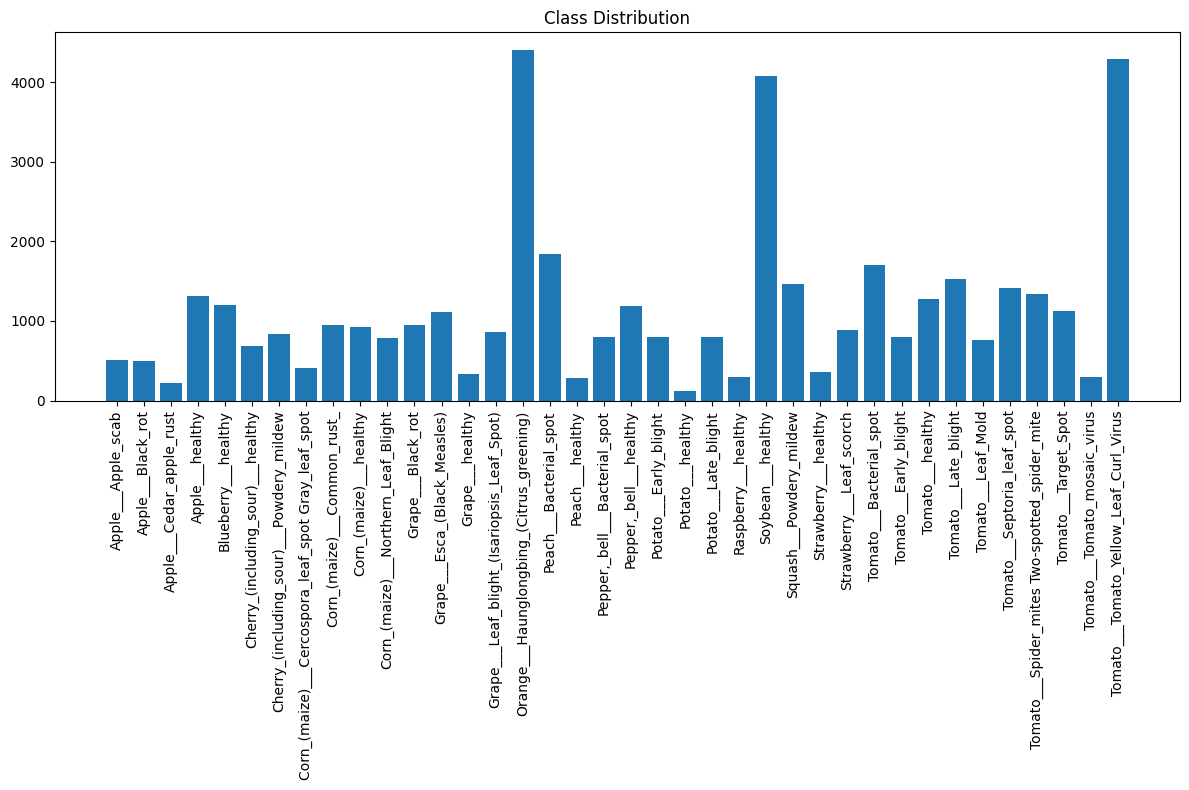

In [7]:
plt.figure(figsize=(12,8))

plt.bar(
    df["Class"],
    df["Training Images"]
)

plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.tight_layout()

plt.show()

Display Sample Images

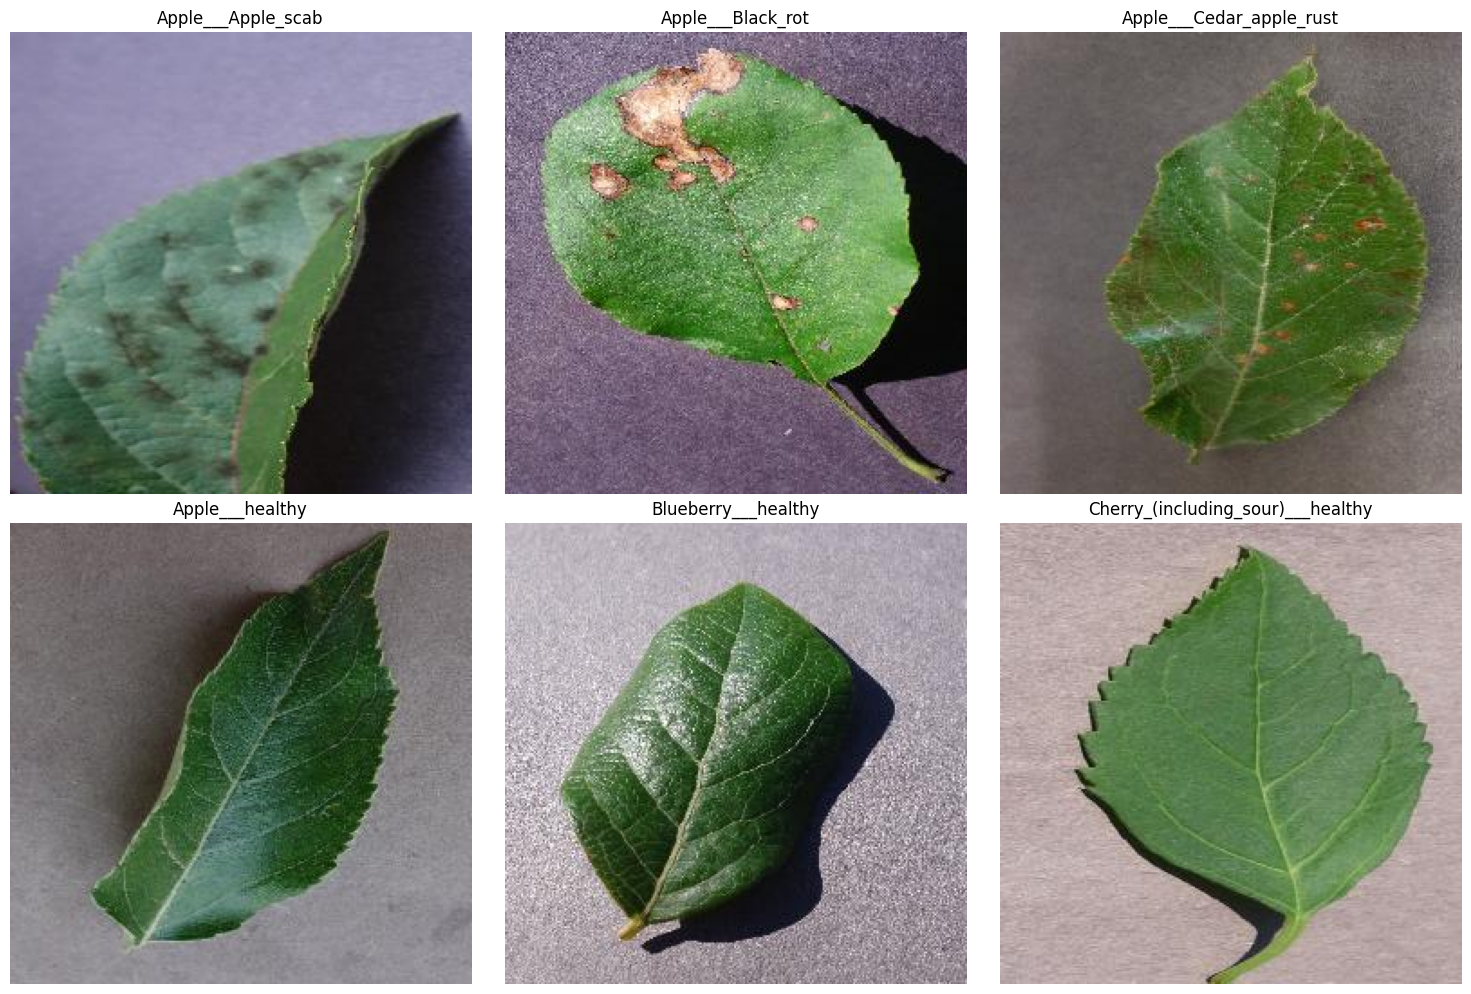

In [8]:
plt.figure(figsize=(15,10))

for i, cls in enumerate(classes[:6]):

    folder = os.path.join(TRAIN_PATH, cls)

    img_name = random.choice(
        os.listdir(folder)
    )

    img_path = os.path.join(
        folder,
        img_name
    )

    img = cv2.imread(img_path)
    img = cv2.cvtColor(
        img,
        cv2.COLOR_BGR2RGB
    )

    plt.subplot(2,3,i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.tight_layout()
plt.show()

Check Image Shape

In [9]:
sample_class = classes[0]

sample_image = random.choice(
    os.listdir(
        os.path.join(
            TRAIN_PATH,
            sample_class
        )
    )
)

img_path = os.path.join(
    TRAIN_PATH,
    sample_class,
    sample_image
)

img = cv2.imread(img_path)

print("Image Shape:", img.shape)

Image Shape: (256, 256, 3)


Image Standardization

In [10]:
IMG_SIZE = 224

img = cv2.imread(img_path)

img = cv2.resize(
    img,
    (IMG_SIZE, IMG_SIZE)
)

img = img / 255.0

print("New Shape:", img.shape)
print("Min Pixel:", img.min())
print("Max Pixel:", img.max())

New Shape: (224, 224, 3)
Min Pixel: 0.01568627450980392
Max Pixel: 0.6549019607843137


DATASET SUMMARY

In [11]:
summary = pd.DataFrame(
    {
        "Item":[
            "Classes",
            "Image Size",
            "Training Classes"
        ],
        "Value":[
            len(classes),
            "224 x 224",
            len(classes)
        ]
    }
)

summary

,Item,Value
0,Classes,38
1,Image Size,224 x 224
2,Training Classes,38


TypeError: Image data of dtype object cannot be converted to float

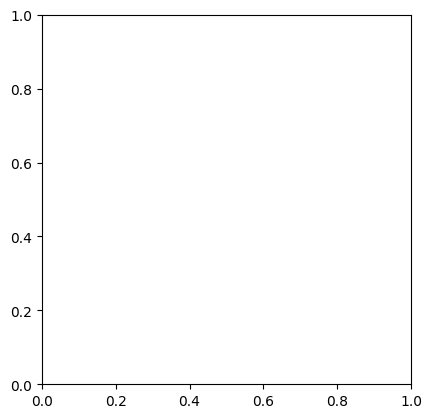

In [12]:
plt.imshow(...)